# **Projet: Analyse d'une boutique en ligne**

Le présent notebook a pour objectif :
- faire un point global sur les principaux indicateurs et chiffres clés de l'entreprise autour du Chiffre d'Affaires, des références produits et de la répartition de la clientèle
- Etablir des liens entre differentes valeurs grâce à des tests statistiques

Après analyse des différents indicateurs, émettre des recommendations.

# **Importation des modules**

In [ ]:
import pandas as pd
import numpy as np

# graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# tests statistiques
from scipy.stats import spearmanr, pearsonr, chi2_contingency
from scipy.stats import f_oneway, kruskal
from scipy.stats import levene

# **Fonctions**

In [ ]:
# Functions to use and reuse

# display the columns
def display_columns_value_counts(df=None):
  """
  Prints the value counts for all columns in a given DataFrame.

  Parameters
  ----------
  df : pandas.DataFrame, optional
      The DataFrame to analyze. If None, an empty DataFrame is used.

  Returns
  -------
  None
      This function prints directly to the console and does not return any value.
  """
  if df is None:
    df = pd.DataFrame()
  else :
    for col in df.columns:
      display(df[col].value_counts(dropna=False))

# Calculate the iqr, lower and upper
def calculate_iqr(df=None, column=None):
  """
  Calculates the Interquartile Range (IQR), lower whisker, and upper whisker for a specified column in a DataFrame.

  Parameters
  ----------
  df : pandas.DataFrame
      The DataFrame containing the data.
  column : str
      The name of the column for which to calculate the IQR and whiskers.

  Returns
  -------
  tuple
      A tuple containing:
      - IQR (float): The Interquartile Range.
      - lower_whisker (float): The lower bound for outlier detection.
      - upper_whisker (float): The upper bound for outlier detection.
  """
  if df is None:
    df = pd.DataFrame()
  else:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR
    return IQR, lower_whisker, upper_whisker

# Turn the month number to a month name for a better visual on the plot
def month_number_to_name(month_number):
  """
  Converts a Series of month numbers (1-12) into an ordered categorical Series of month names (Janvier-Décembre).

  Parameters
  ----------
  month_number : pandas.Series
      A Series containing month numbers (integers from 1 to 12).

  Returns
  -------
  pandas.Series
      An ordered categorical Series with French month names.
  """
  map_months_name = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril', 5: 'Mai', 6: 'Juin',
    7: 'Juillet', 8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
  }

  month_order = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin', 'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']
  month_name = month_number.map(map_months_name).astype('category').cat.reorder_categories(
    new_categories=month_order,
    ordered=True)
  return month_name

# **Importation des fichiers CSV**

In [ ]:
# Importation des fichiers CSV

customers = pd.read_csv('data/customers.csv', sep=',')
products = pd.read_csv('data/products.csv', sep=',')
transactions = pd.read_csv('data/transactions.csv', sep=',')

# **Exploration du jeu de données "Customers"**




In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [ ]:
display_columns_value_counts(customers)

,count
client_id,
c_84,1
c_4410,1
c_7839,1
c_1699,1
c_5961,1
...,...
c_7049,1
c_6616,1
c_5019,1


,count
sex,
f,4491
m,4132


,count
birth,
2004,440
1979,215
1988,207
1986,203
1978,199
...,...
1935,8
1932,6
1931,4


In [ ]:
# Number of uniques values of the id
print(f"Number of unique ids {customers['client_id'].nunique()} over {len(customers)} rows")

# Problèmes de formattage
ids_not_formatted = customers['client_id'].str.contains('c_').count()
print(f'Lines well formatted : {ids_not_formatted}')

Number of unique ids 8623 over 8623 rows
Lines well formatted : 8623


In [ ]:
# est-ce qu'il y a des valeurs nulles dans la date
print(f'Nombre de valeurs nulles dans l\'année de naissance : {customers["birth"].isnull().sum()}')

Nombre de valeurs nulles dans l'année de naissance : 0


# **Exploration du jeu de données "Transactions"**



## **Initialisation**

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB


In [ ]:
transactions.head()

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232


In [ ]:
display_columns_value_counts(transactions)

,count
id_prod,
1_369,2252
1_417,2189
1_414,2180
1_498,2128
1_425,2096
...,...
2_81,1
0_886,1
0_1379,1


,count
date,
test_2021-03-01 02:30:02.237413,13
test_2021-03-01 02:30:02.237428,8
test_2021-03-01 02:30:02.237443,8
test_2021-03-01 02:30:02.237444,8
test_2021-03-01 02:30:02.237427,8
...,...
2022-07-14 13:51:26.533057,1
2021-05-09 01:09:02.838161,1
2021-09-30 09:55:27.316636,1


,count
session_id,
s_0,200
s_118668,14
s_96857,13
s_215292,13
s_342045,13
...,...
s_3255,1
s_278388,1
s_128428,1


,count
client_id,
c_1609,25488
c_6714,9187
c_3454,6773
c_4958,5195
c_3263,403
...,...
c_5962,1
c_1624,1
c_4648,1


## **Problèmes de formattage**

Certains produits sessions et clients semblent être des tests de fonctionnement qui ne representent pas de vrais flux de vente. Donc à exclure de l'analyse.

In [ ]:
test_products = transactions[transactions["id_prod"]=="T_0"]["id_prod"]

In [ ]:
# exclude test session that does seems to result as real sales
transactions = transactions[~transactions["id_prod"].isin(test_products)]

In [ ]:
# deletion of the timestamp to get a normal date
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce').dt.date

Vérifier que tous les identifiants soient bien également standardisés

In [ ]:
# see if there are ids bad formated
client_id_formated = transactions['client_id'].str.startswith('c_').sum()
session_id_formated = transactions['session_id'].str.startswith('s_').sum()
id_prod_formated = transactions['id_prod'].str.startswith(('0_', '1_', '2_')).sum()

# see the format of all
print(f"Identifiants clients bien formatés : {client_id_formated} over {len(transactions['client_id'])}")
print(f"Identifiants sessions bien formatés : {session_id_formated} over {len(transactions['session_id'])}")
print(f"Identifiants produits bien formatés : {id_prod_formated} over {len(transactions['id_prod'])}")

# the contrary of .contains
# identifiants mal formatés
# not contains

Identifiants clients bien formatés : 679332 over 679332
Identifiants sessions bien formatés : 679332 over 679332
Identifiants produits bien formatés : 679332 over 679332


In [ ]:
# delete the nulls and the ids that are duplicated
transactions.drop_duplicates(subset=['id_prod', 'session_id', 'client_id'], inplace=True)
transactions.dropna(subset=['id_prod', 'session_id', 'client_id'], inplace=True)

In [ ]:
# exploration du champs id_prod, session_id et client_id qui semblent être la clé primaires
transactions_id = transactions[['id_prod', 'session_id', 'client_id']]

# Duplicated number of lines
print(f'Nombre de lignes avec un id dupliqué : {transactions_id.duplicated().sum()}')

duplicated_lignes = transactions_id[transactions_id.duplicated(keep=False)]
display(duplicated_lignes)

Nombre de lignes avec un id dupliqué : 0


,id_prod,session_id,client_id


# **Exploration du jeu de données "Products"**

## **Initialisation**

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB


In [ ]:
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [ ]:
display_columns_value_counts(products)

,count
id_prod,
0_1920,1
0_1421,1
0_1368,1
0_731,1
1_587,1
...,...
1_178,1
2_228,1
0_389,1


,count
price,
4.99,85
6.99,84
3.99,80
5.99,78
8.99,74
...,...
45.03,1
4.19,1
9.61,1


,count
categ,
0,2309
1,739
2,239


## **Eléments dupliqués**

In [ ]:
# Not nulls and duplicated ids
print(f'Number of duplicated lines : {products["id_prod"].duplicated().sum()}')
print(f'Number of nulls: {products["id_prod"].isnull().sum()}')

Number of duplicated lines : 0
Number of nulls: 0


## **Renommage et changement de type de données**

In [ ]:
# change the name and switch the type to category
products = products.rename(columns={'categ': 'category'})
products['category'] = products['category'].astype('category')

## **Analyse des prix et détection des outliers**

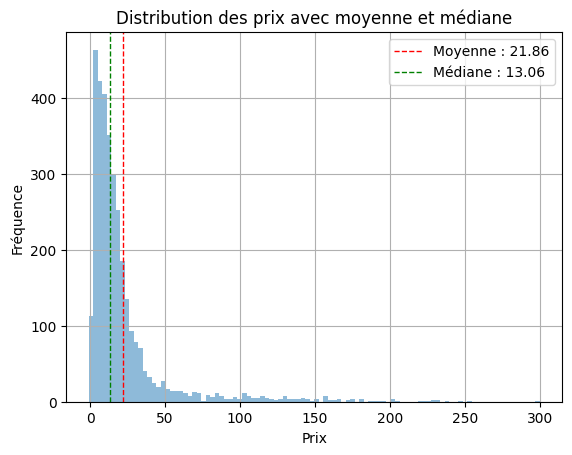

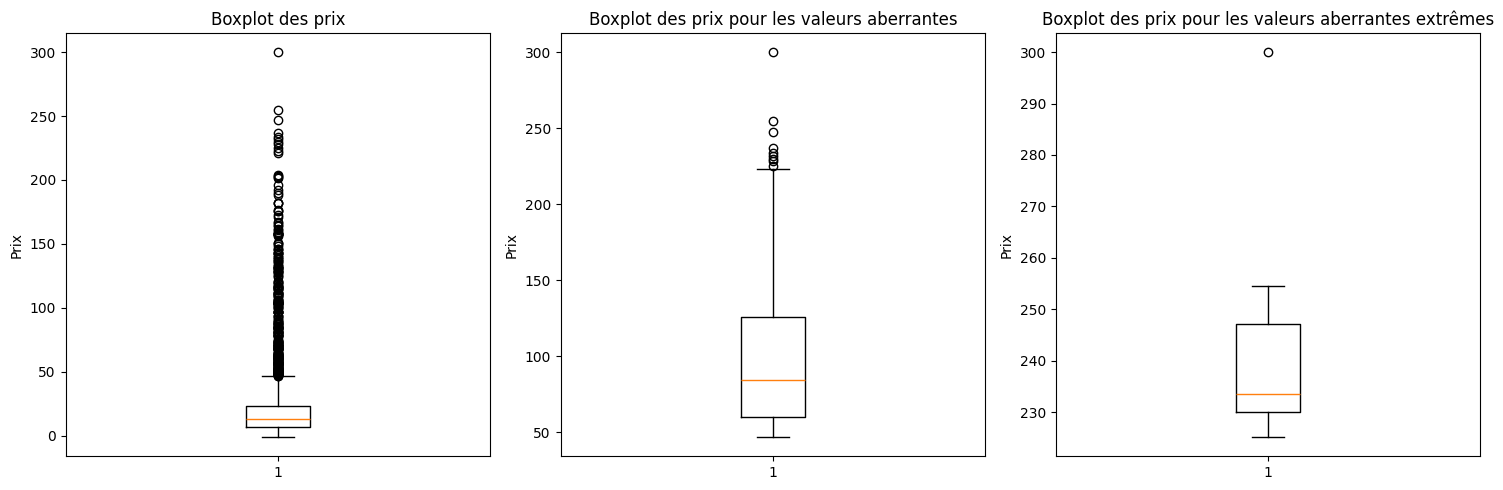

In [ ]:
# Calculate mean and median
mean_price = products['price'].mean()
median_price = products['price'].median()

# Add vertical lines for mean and median
plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=1, label=f'Moyenne : {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=1, label=f'Médiane : {median_price:.2f}')

# What are the prices which are displayed
products['price'].hist(bins=100, alpha=0.5)
plt.xlabel('Prix')
plt.ylabel('Fréquence')
plt.title('Distribution des prix avec moyenne et médiane')
plt.legend()
plt.show()

# Calculate the iqr if the products are not empty
if not products.empty:
  iqr, lower_whisker, upper_whisker = calculate_iqr(products, 'price')
  outliers = products[products['price'] > upper_whisker]

# Calculate the iqr for the outliers are not empty
if not outliers.empty:
  iqr_outliers, lower_whisper_outliers, upper_whisker_outliers = calculate_iqr(outliers, 'price')
  outliers_beyond = outliers[outliers['price'] > upper_whisker_outliers]


levels = [products, outliers, outliers_beyond]
fig, ax = plt.subplots(1, len(levels), figsize=(15, 5))
for i, data in enumerate(levels):
  if not data.empty:
    ax[i].boxplot(data=data, x='price')
    if i == 0:
      title = 'Boxplot des prix'
    elif i == 1:
      title = 'Boxplot des prix pour les valeurs aberrantes'
    else:
      title = 'Boxplot des prix pour les valeurs aberrantes extrêmes'
    ax[i].set_title(title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Prix')
  else:
    ax[i].set_visible(False)


plt.tight_layout()

plt.show()

In [ ]:
products["price"].count()

np.int64(3287)

In [ ]:
outliers["price"].count()

np.int64(302)

In [ ]:
outliers_beyond["price"].count()

np.int64(9)

Il apparaît une **hétérogénéité marquée des prix** entre les différents produits.  
La **majorité des références** présentent un prix plafonnant autour de **50 €**, tandis que **certains produits se distinguent par des prix nettement plus élevés**, pouvant atteindre **260 €**.

# **Consolidation des données**

## **"Customers" et "Transactions"**

In [ ]:
# check if all the ids match or if there are some null values
customers_transactions_df = pd.merge(transactions, customers, on='client_id', how='left', indicator=True)

In [ ]:
customers_transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678505 entries, 0 to 678504
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id_prod     678505 non-null  object  
 1   date        678505 non-null  object  
 2   session_id  678505 non-null  object  
 3   client_id   678505 non-null  object  
 4   sex         678505 non-null  object  
 5   birth       678505 non-null  int64   
 6   _merge      678505 non-null  category
dtypes: category(1), int64(1), object(5)
memory usage: 31.7+ MB


In [ ]:
lines_correspondance_free = (customers_transactions_df["_merge"]!="both").sum()
print(f"Nombre de lignes sans correspondance: {lines_correspondance_free}")

Nombre de lignes sans correspondance: 0


In [ ]:
customers_transactions_df.drop("_merge", axis=1, inplace=True)

In [ ]:
customers

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
...,...,...,...
8618,c_7920,m,1956
8619,c_7403,f,1970
8620,c_5119,m,1974
8621,c_5643,f,1968


## **Fusion précédente et "products"**

In [ ]:
# check if there are some null values with the ids from products
customers_transactions_products_df = pd.merge(customers_transactions_df, products, on='id_prod', how='left', indicator=True)

In [ ]:
customers_transactions_products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678505 entries, 0 to 678504
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   id_prod     678505 non-null  object  
 1   date        678505 non-null  object  
 2   session_id  678505 non-null  object  
 3   client_id   678505 non-null  object  
 4   sex         678505 non-null  object  
 5   birth       678505 non-null  int64   
 6   price       678284 non-null  float64 
 7   category    678284 non-null  category
 8   _merge      678505 non-null  category
dtypes: category(2), float64(1), int64(1), object(5)
memory usage: 37.5+ MB


In [ ]:
lines_correspondance_free = customers_transactions_products_df.loc[customers_transactions_products_df["_merge"]!="both", "_merge"].count()
print(f"Nombre de lignes sans correspondance: {lines_correspondance_free}")

Nombre de lignes sans correspondance: 221


Suppression des valeurs nulles issues de la jonction par la gauche ayant provoqué des lignes sans jonctions

In [ ]:
customers_transactions_products_df.dropna(subset=["price", "category"], inplace=True)

# **Analyse du chiffre d'affaires**

## **Chiffre d'affaires total**

In [ ]:
global_turnover = customers_transactions_products_df['price'].sum()
print(f'Le CA total est de {global_turnover: .2f} euros')

Le CA total est de  11836496.99 euros


## **Évolution du chiffre d'affaires dans le temps**

In [ ]:
customers_transactions_products_df["date"].isna().sum()

np.int64(0)

In [ ]:
# Convert the 'date' column to datetime objects
customers_transactions_products_df['date'] = pd.to_datetime(customers_transactions_products_df['date'])

# split the date into several time periods
customers_transactions_products_df['day'] = customers_transactions_products_df['date'].dt.day
customers_transactions_products_df['year'] = customers_transactions_products_df['date'].dt.year
customers_transactions_products_df['month'] = customers_transactions_products_df['date'].dt.month

for col in ["day", "year", "month"]:
  customers_transactions_products_df[col] = customers_transactions_products_df[col].astype(int)

### **Par an**

/tmp/ipython-input-1176166406.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


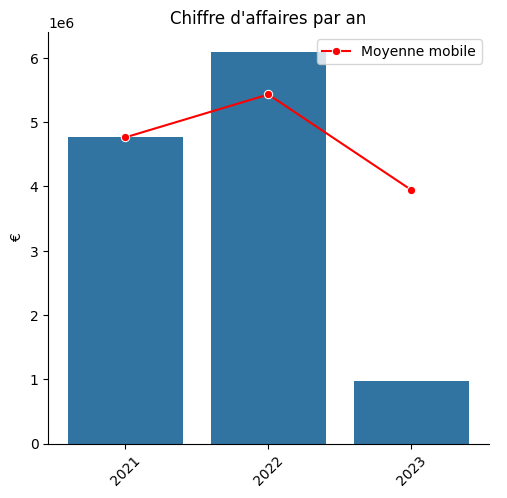

In [ ]:
# turnover per year
turnover_per_year = customers_transactions_products_df.groupby('year', as_index=False)['price'].agg(
    total_turnover='sum',
)

turnover_per_year['rolling_avg'] = turnover_per_year['total_turnover'].rolling(min_periods=1, window=3).mean()

turnover_per_year = turnover_per_year.sort_values('year', ascending=True)
turnover_per_year['year'] = turnover_per_year['year'].astype('str')
g = sns.catplot(x='year',
                 y='total_turnover',
                 data=turnover_per_year,
                 kind='bar')

for ax in g.axes.flat:
  sns.lineplot(x='year',
               y='rolling_avg',
               data=turnover_per_year,
               ax=ax,
               color='red',
               marker='o',
               label="Moyenne mobile")
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
g.ax.set_title('Chiffre d\'affaires par an')
g.ax.set_xlabel('')
g.ax.set_ylabel('€')
plt.show()

Basé sur le graphique au-dessus, le chiffre d'affaires a connu une **appréciation significative de de +1M€ entre 2021 et 2022**. Pour 2023, il est impossible pour le moment d'établir quelconque constat car les données ne sont disponibles que pour janvier et février.

### **Par mois**

Intéressant de pouvoir également établir une évolution mensuelle pour les différentes annnées

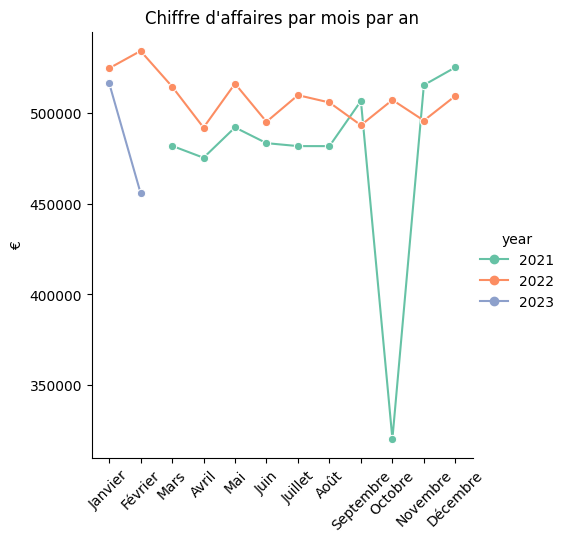

In [ ]:
# turnover per month
turnover_per_month = customers_transactions_products_df.groupby(['year', 'month'], as_index=False)['price'].agg(
    total_turnover='sum'
)
turnover_per_month = turnover_per_month.sort_values(['year', 'month'], ascending=True)

# Rolling avg
turnover_per_month['rolling_avg'] = turnover_per_month['total_turnover'].rolling(window=12, min_periods=1).mean()

turnover_per_month['month_name'] = month_number_to_name(turnover_per_month['month'])


sns.relplot(x='month_name', y='total_turnover', hue='year', data=turnover_per_month, kind='line', palette='Set2', marker='o')
plt.xlabel('')
plt.ylabel('€')
plt.title('Chiffre d\'affaires par mois par an')
plt.xticks(rotation=45)
plt.show()

Un graphique difficile à exploiter à cause du manque de données pour 2023 et des données pour 2021 et 2021 assez peu lisibles.

## **Décomposition de la moyenne mobile du chiffre d'affaires**

Idenfier et quantifier les différents leviers permettant d'expliquer l'évolution du chiffre d'affaires dans le temps à travers:
- **les données de base à travers le temps**
- **la tendance:** l'évolution de fond sur le long-terme
- **la saisonnalité:** observer si des variations apparaissent selon les périodes
- **les résidus:** tout le reste des données qui ne peuvent pas être expliquées

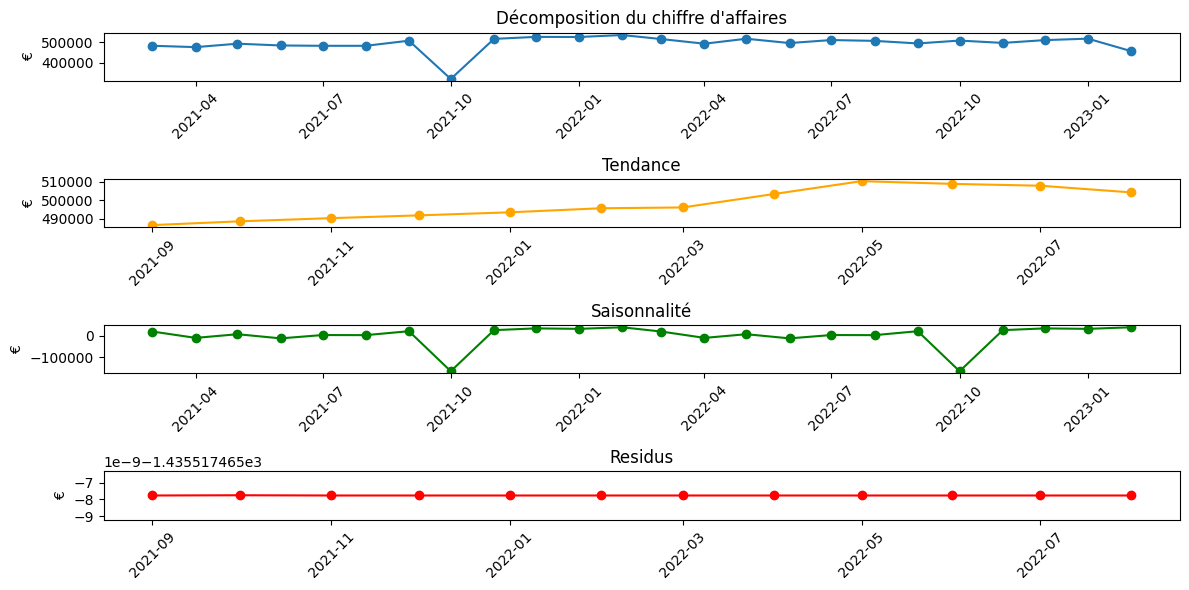

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

turnover_per_month_cp = turnover_per_month.copy()

turnover_per_month_cp["date"] = pd.to_datetime(turnover_per_month_cp["year"].astype(int).astype(str) + "-" + turnover_per_month_cp["month"].astype(int).astype(str) + "-01")

turnover_per_month_cp.set_index("date", inplace=True)

decomposition = seasonal_decompose(turnover_per_month_cp['total_turnover'], model='additive', period=12)


# decomposition of all the various data that will ploted
original = decomposition.observed
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12, 6))

for i, data in enumerate([original, trend, seasonal, residual]):
  plt.subplot(4, 1, i + 1)
  if i == 0:
    plt.title("Décomposition du chiffre d'affaires")
    plt.plot(data, label="Chiffre d'affaires original", marker="o")
  elif i==1:
    plt.title("Tendance")
    plt.plot(data, label="Tendance", color="orange", marker="o")
  elif i==2:
    plt.title("Saisonnalité")
    plt.plot(data, label="Saisonnalité", color="green", marker="o")
  else:
    plt.title("Residus")
    plt.plot(data, label="Résidus", color="red", marker="o")
  plt.xticks(rotation=45)
  plt.ylabel("€")
plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()


Grâce à la décomposition du chiffre d’affaires, la **tendance de fond apparaît globalement à la hausse**.

Par ailleurs, un **changement de comportement des clients** semble se manifester à partir du **mois d’octobre**, période à laquelle les **ventes enregistrent un fort déclin**, traduisant pour une periode très courte un effet défavorable.

## **Chiffre d'affaires par catégorie**

**Quelles sont les catégories qui impactent le plus le chiffre d'affaires ?**

/tmp/ipython-input-2791846527.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  turnover_per_category = customers_transactions_products_df.groupby(['year', 'month', 'category'], as_index=False)['price'].sum()
/tmp/ipython-input-2791846527.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-2791846527.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-2791846527.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

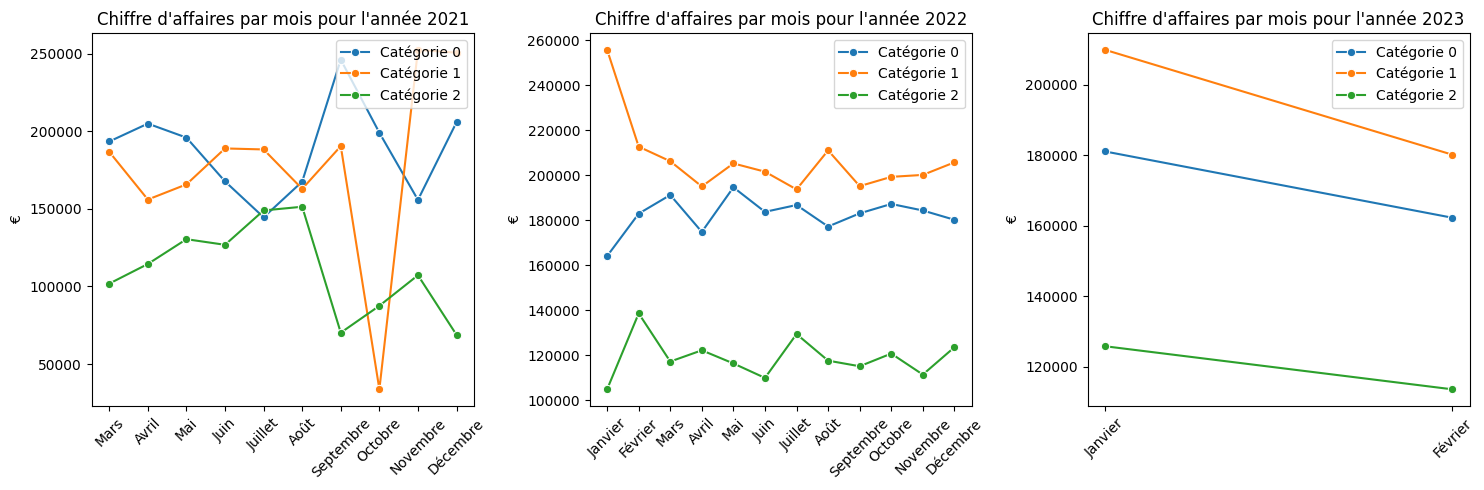

/tmp/ipython-input-2791846527.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.catplot(data=turnover_per_category,


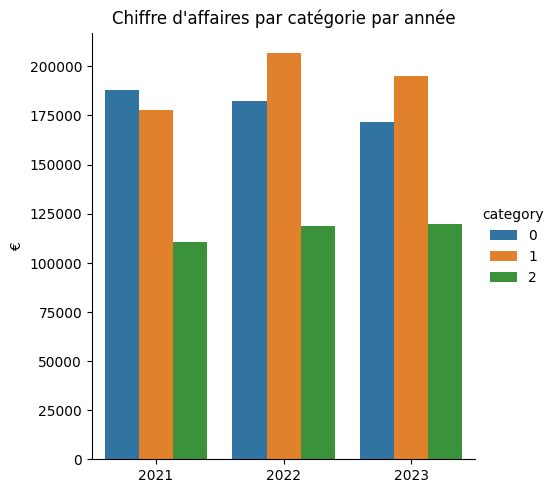

In [ ]:
# turnover per category
turnover_per_category = customers_transactions_products_df.groupby(['year', 'month', 'category'], as_index=False)['price'].sum()
turnover_per_category.sort_values('category', ascending=True, inplace=True)

turnover_per_category['month_name'] = month_number_to_name(turnover_per_category['month'])

# To avoid showing the month where there is no data
turnover_per_category.loc[turnover_per_category['price'] == 0, 'price'] = np.nan

fig, ax = plt.subplots(1, turnover_per_category['year'].nunique(), figsize=(15, 5))

for i, year in enumerate(turnover_per_category['year'].unique()):
  data_category = turnover_per_category[turnover_per_category["year"] == year]

  ax[i].set_title(f'Chiffre d\'affaires par mois pour l\'année {year}')
  sns.lineplot(data=data_category,
               x='month_name', y='price',
               hue="category",
               marker='o',
               ax=ax[i])
  ax[i].set_xlabel('')
  ax[i].set_ylabel('€')

  # Customize the legend labels
  handles, labels = ax[i].get_legend_handles_labels()
  ax[i].legend(handles, ['Catégorie ' + label for label in labels], loc='upper right')
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
  plt.subplots_adjust(wspace=0.8)
plt.tight_layout()
plt.show()


sns.catplot(data=turnover_per_category,
            kind="bar",
            x="year",
            y="price", hue="category",
            ci=False)
plt.title('Chiffre d\'affaires par catégorie par année')
plt.xlabel('')
plt.ylabel('€')
plt.show()

/tmp/ipython-input-3182485805.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_distribution = customers_transactions_products_df.groupby('category', as_index=False)['price'].sum()


Text(0.5, 1.0, "Répartition du chiffre d'affaires par catégorie")

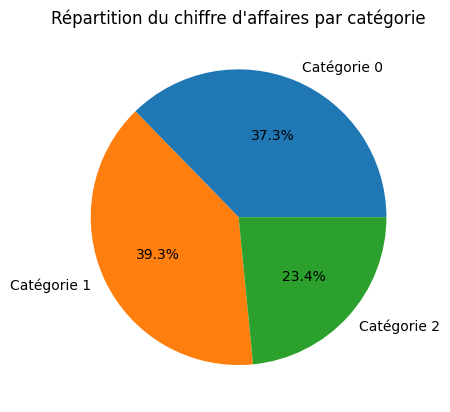

In [ ]:
# Category distribution
category_distribution = customers_transactions_products_df.groupby('category', as_index=False)['price'].sum()
category_distribution.plot(kind='pie',
                           y='price',
                           labels=['Catégorie '+ str(cat) for cat in category_distribution["category"].unique()],
                           autopct='%1.1f%%',
                           legend=None)
plt.ylabel('')
plt.title('Répartition du chiffre d\'affaires par catégorie')

La **catégorie 1** est celle qui **contribue le plus au chiffre d’affaires**, suivie de **très près par la catégorie 0**.  
La **catégorie 2** complète le podium, mais apparaît comme **légèrement moins plébiscitée par la clientèle**.

## **Meilleures et pires ventes**

Identifier les **meilleures et les moins bonnes ventes** est essentiel afin de déterminer **les produits à développer** et ceux qui pourraient être **progressivement arrêtés**, en raison d’un **intérêt insuffisant de la part des clients**.

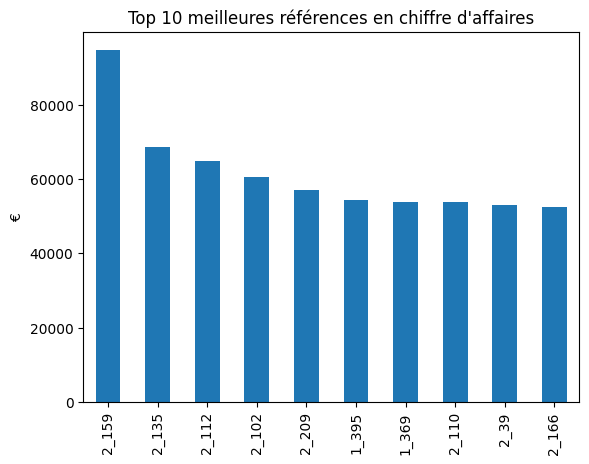

In [ ]:
# Tops products
sales_product = customers_transactions_products_df.groupby('id_prod', as_index=False)['price'].sum()
top_references = sales_product.sort_values('price', ascending=False)
top_references = top_references.head(10)
top_references.plot(kind='bar', x='id_prod', legend=False)
plt.xlabel('')
plt.ylabel('€')
plt.title('Top 10 meilleures références en chiffre d\'affaires')
plt.show()

Les meilleures références dépassant les **40 k€ de chiffre d’affaires**, la clientèle cible semble présenter des **besoins importants en termes de volume**.  
Ce constat suggère que l’entreprise s’adresse également à une **clientèle professionnelle**, en complément d’une clientèle particulière.

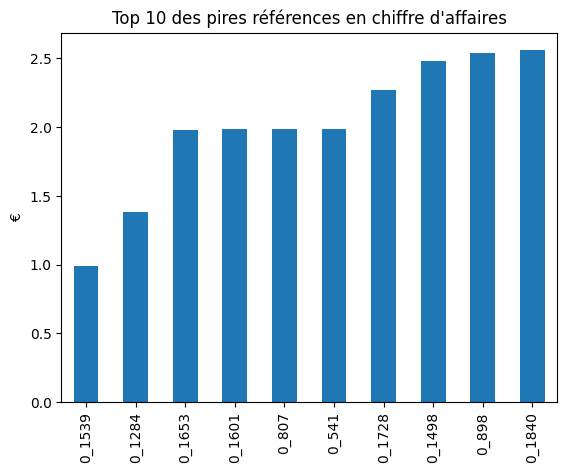

In [ ]:
# Worst products
worst_references = sales_product.sort_values('price', ascending=True).head(10)

worst_references.plot(kind='bar',
                      x='id_prod',
                      legend=None)
plt.xlabel('')
plt.ylabel('€')
plt.title('Top 10 des pires références en chiffre d\'affaires')
plt.show()

Certaines références ne dépassent pas les **2,50 € de chiffre d’affaires**, ce qui traduit un **très faible intérêt de la part des clients** pour ces produits.  
Ce constat peut conduire l’entreprise à **repenser son offre**, soit en **introduisant de nouvelles références** mieux alignées avec les besoins des clients, soit en **abandonnant ces produits** peu performants.

# **Evolution du nombre de clients acquis**

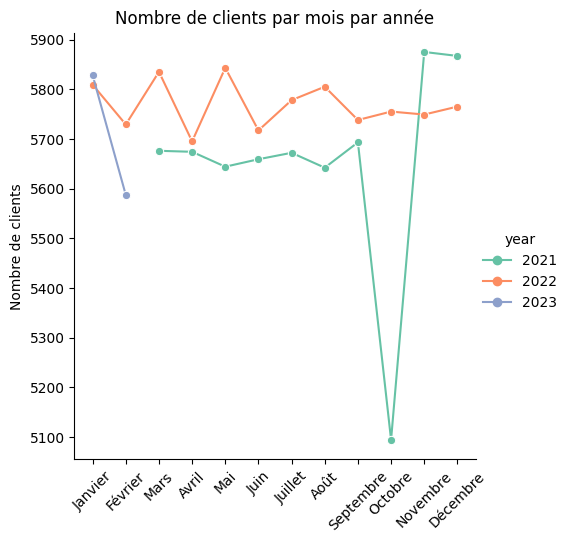

In [ ]:
# Number of customers per month
customers_per_month = customers_transactions_products_df.groupby(['year','month'], as_index=False)['client_id'].nunique()
customers_per_month = customers_per_month.sort_values(['year', 'month'], ascending=True)

customers_per_month['month_name'] = month_number_to_name(customers_per_month['month'])

g = sns.relplot(x='month_name',
                 y='client_id',
                hue='year',
                 data=customers_per_month,
                kind='line',
                palette='Set2',
                marker='o')
plt.xlabel('')
plt.ylabel('Nombre de clients')
plt.title('Nombre de clients par mois par année')
plt.xticks(rotation=45)
plt.show()

# **Nombre de transactions**

The number of transactions is 678284


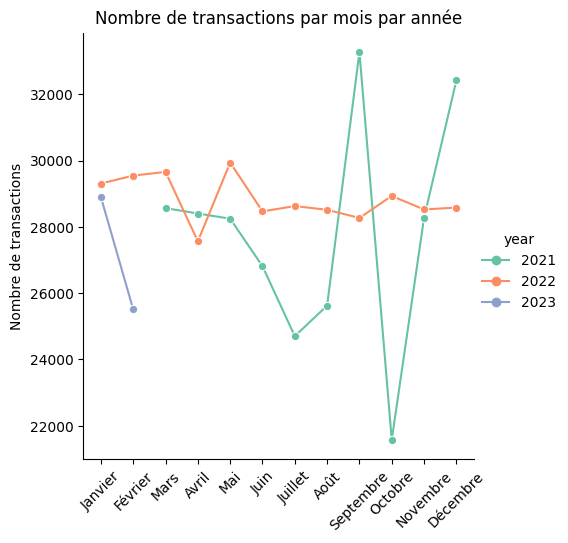

In [ ]:
# Number of transactions
number_transactions = customers_transactions_products_df['date'].count()
print(f'The number of transactions is {number_transactions}')

# Number of sales transactions
sales_per_month_year = customers_transactions_products_df.groupby(['year','month'], as_index=False)['date'].count()
sales_per_month_year = sales_per_month_year.sort_values(['year', 'month'], ascending=True)

sales_per_month_year['month_name'] = month_number_to_name(sales_per_month_year['month'])

sns.relplot(kind='line',
            data=sales_per_month_year,
            x='month_name',
            y='date',
            hue='year',
            palette='Set2',
            marker='o')

plt.xlabel('')
plt.ylabel('Nombre de transactions')
plt.title('Nombre de transactions par mois par année')
plt.xticks(rotation=45)
plt.show()

# **Nombre de produits vendus dans le temps**

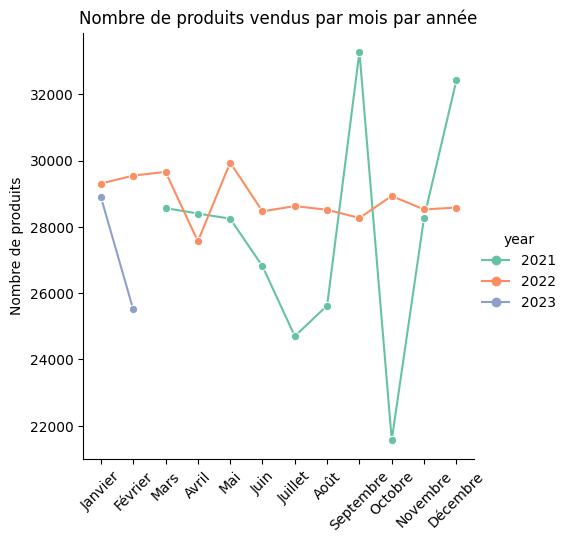

In [ ]:
number_products_sold = customers_transactions_products_df.groupby(["year", "month"], as_index=False)['id_prod'].count()\
.sort_values(["year", "month"], ascending=True)

number_products_sold["month_name"] = month_number_to_name(number_products_sold["month"])

sns.relplot(kind='line',
            data=number_products_sold,
            x='month_name',
            y='id_prod',
            hue='year',
            palette='Set2',
            marker='o')

plt.xlabel('')
plt.ylabel('Nombre de produits')
plt.title('Nombre de produits vendus par mois par année')
plt.xticks(rotation=45)
plt.show()

Le nombre de transactions est égal au nombre de produits vendus, ce qui veut dire que chaque transaction enregistré avec une date équivaut à une vente

In [ ]:
cross_metrics_year_month = pd.merge(turnover_per_month, sales_per_month_year, on=['year', 'month', 'month_name'], how='left').merge(customers_per_month, on=['year', 'month', 'month_name'], how='left')

In [ ]:
cross_metrics_year_month.sort_values(["year", "month"], ascending=True, inplace=True)
cross_metrics_year_month.drop(["rolling_avg", "month"], axis=1, inplace=True)
cross_metrics_year_month.rename(columns={'total_turnover': 'turnover', 'date': 'sales', 'client_id': 'customers'}, inplace=True)

In [ ]:
  cross_metrics_year_month['unit_price_sold'] = np.round(cross_metrics_year_month['turnover'] / cross_metrics_year_month['sales'], 2)
  cross_metrics_year_month['sales_per_customer'] = np.round(cross_metrics_year_month['sales'] / cross_metrics_year_month['customers'], 2)
  cross_metrics_year_month['turnover_per_customer'] = np.round(cross_metrics_year_month['turnover'] / cross_metrics_year_month['customers'], 2)


# **Profils clients**

## **Répartition de la clientèle**

**Connaître ma clientèle: genre, âge et leur type en fonction du volume acheté**

In [ ]:
# Calculate the age for each customers
age_customer = pd.Timestamp.today().year - customers_transactions_products_df['birth']
customers_transactions_products_df['age'] = age_customer

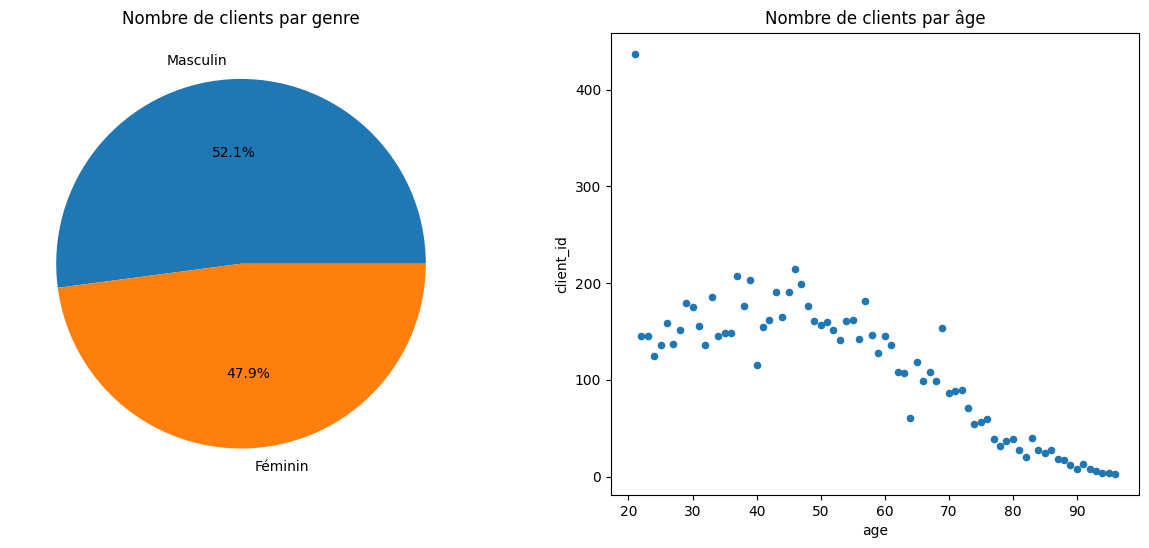

In [ ]:
# Number of customers per gender
customers_per_gender = customers_transactions_products_df.groupby('sex', as_index=False)['client_id'].nunique()
customers_per_age = customers_transactions_products_df.groupby('age', as_index=False)['client_id'].nunique()

fig, ax = plt.subplots(1, len([customers_per_gender, customers_per_age]), figsize=(15, 6))

for i, data in enumerate([customers_per_gender, customers_per_age]):
  if i == 0:
    ax[i].set_title('Nombre de clients par genre')
    customers_per_gender.plot(kind='pie',
                              y='client_id',
                              labels=['Masculin', 'Féminin'],
                              autopct='%1.1f%%', legend=None, ax=ax[i])
    ax[i].set_ylabel('')
  else:
    ax[i].set_title('Nombre de clients par âge')
    ax[i].set_xlabel('Âge')
    ax[i].set_ylabel('Nombre de clients')
    customers_per_age.plot(kind='scatter', x='age', y='client_id', ax=ax[i])
plt.show()

Clientèle hétérogène entre 20 et 60 ans légèrement masculine (52.1%)

## **Courbe de Lorenz: définir pour chaque pour % de clients le % de chiffre d'affaires généré**

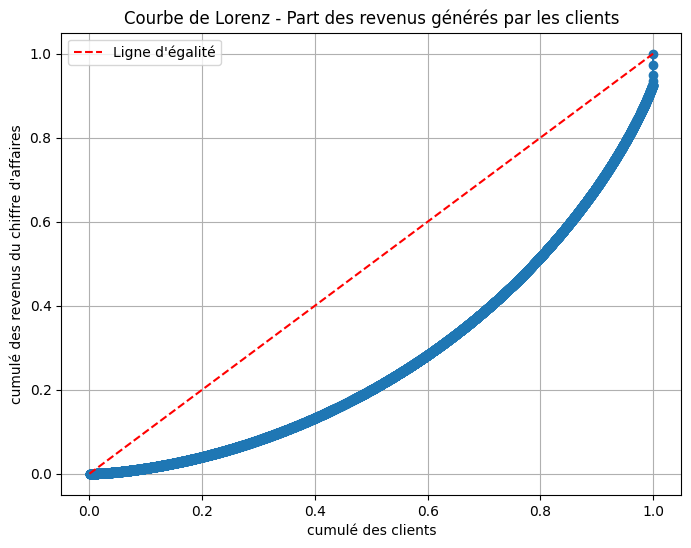

In [ ]:
# Calculate the total amount spent per customer
customer_revenue = customers_transactions_products_df.groupby('client_id', as_index=False)['price'].sum()
customer_revenue_srt = customer_revenue.sort_values('price', ascending=True)

# Calculate the cumulative sum of revenue
customer_revenue_srt = customer_revenue_srt['price'].cumsum()

# np.arange : loop from 1 to the last index + 1 to include the last value
cumulative_customer_percentage = np.arange(1, len(customer_revenue_srt) + 1) / len(customer_revenue_srt)

# cumulative revenue / total cumulative revenue (-1 -> last index)
cumulative_revenue_percentage = customer_revenue_srt / customer_revenue_srt.iloc[-1]

# Plot the Lorenz curve
plt.figure(figsize=(8, 6))
plt.plot(cumulative_customer_percentage, cumulative_revenue_percentage, marker='o', linestyle='-')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ligne d\'égalité') # Line of perfect equality
plt.title('Courbe de Lorenz - Part des revenus générés par les clients')
plt.xlabel('cumulé des clients')
plt.ylabel('cumulé des revenus du chiffre d\'affaires')
plt.grid(True)
plt.legend()
plt.show()

## **Loi de pareto 20-80**

In [ ]:
# Look at the percentage of the customers who are making
eighty_percent = customer_revenue['price'].sum() * 0.8

# keep the top customers
# Sort in descending order to get the top spenders
top_80percent = customer_revenue.sort_values('price', ascending=False)

# Calculate the cumulative sum from the highest spenders
top_80percent['cumulative_price'] = top_80percent['price'].cumsum()

# Select customers who contribute to the top 80% of the total turnover
top_80percent = top_80percent[top_80percent['cumulative_price'] <= eighty_percent]

print(f"80% du chiffre d'affaires est généré par {(top_80percent["client_id"].nunique()/customers_transactions_products_df["client_id"].nunique())*100:.2f}% \
de la clientèle totale")

80% du chiffre d'affaires est généré par 49.93% de la clientèle totale


La loi de pareto confirme la courbe de Lorenz où 80% du chiffre d'affaire est réalisé par la moitié des clients

## **Définition des clients professionnels : B2B**

Pour différencier un client professionnel d'un particulier, un seuil minimum a été défini basé sur le jeu de donnée calculé dans la phase précédente. POur rappel, il permet de définir les clients qui génèrent 80% et 20% du CA.
Prenons comme hypothèse que les clients qui génèrent 20% du CA sont cosidérés comme particuliers et le reste comme des professionnels.

POur définir le seuil qui servira de base à la définition du client, j'ai donc pris le prix minimum au sein des clients qui génèrent 80% du CA. J'ai ensuite utilisé ce seuil comme un filtre:
- Si le prix est > seuil alors le client est considéré comme professionnel
- Si le prix est < seuil, alors le client est considéré comme particulier

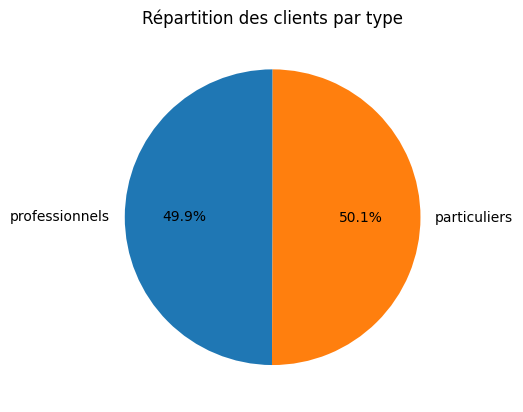

In [ ]:
# Turnover for B2B customers

# turnover minimum made by those who generated the more important revenue for the companies
amount_minimum = top_80percent['price'].min()

# compare the turnover to the minimum to determine the type of customers
b2b_customers = customer_revenue[customer_revenue['price'] >= amount_minimum]
b2c_customers = customer_revenue[customer_revenue['price'] < amount_minimum]

plt.pie([len(b2b_customers), len(b2c_customers)],
        labels=['professionnels', 'particuliers'],
        autopct='%1.1f%%',
        startangle=90)
plt.title('Répartition des clients par type')
plt.show()


Le pie plot et la loi de Pareto confirme un équilibre quasi parfait entre le **nombre de clients particuliers et professionnels**.

In [ ]:
# specify a label to identify which customer is professional or a particular
customers_transactions_products_df['type_customer'] = "Particuliers"
mask = customers_transactions_products_df['client_id'].isin(b2b_customers['client_id'])
customers_transactions_products_df.loc[mask, 'type_customer'] = "Professionnels"

In [ ]:
# check if the type_customer was perfectly filled'
customers_transactions_products_df

,id_prod,date,session_id,client_id,sex,birth,price,category,_merge,day,year,month,age,type_customer
0,0_1518,2022-05-20,s_211425,c_103,f,1986,4.18,0,both,20,2022,5,39,Professionnels
1,1_251,2022-02-02,s_158752,c_8534,m,1988,15.99,1,both,2,2022,2,37,Professionnels
2,0_1277,2022-06-18,s_225667,c_6714,f,1968,7.99,0,both,18,2022,6,57,Professionnels
3,2_209,2021-06-24,s_52962,c_6941,m,2000,69.99,2,both,24,2021,6,25,Particuliers
4,0_1509,2023-01-11,s_325227,c_4232,m,1980,4.99,0,both,11,2023,1,45,Professionnels
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678500,0_1551,2022-01-15,s_150195,c_8489,f,1951,12.99,0,both,15,2022,1,74,Professionnels
678501,1_639,2022-03-19,s_181434,c_4370,f,1977,10.99,1,both,19,2022,3,48,Professionnels
678502,0_1425,2022-12-20,s_314704,c_304,f,1988,12.99,0,both,20,2022,12,37,Professionnels
678503,0_1994,2021-07-16,s_63204,c_2227,m,1986,4.98,0,both,16,2021,7,39,Professionnels


In [ ]:
customers_transactions_products_df["category"].value_counts(dropna=False)

,count
category,
0,415010
1,226891
2,36383


/tmp/ipython-input-1634105744.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('category', as_index=False)['price'].sum()


  category       price
0        0  3569626.84
1        1  3558099.72
2        2  2340690.18


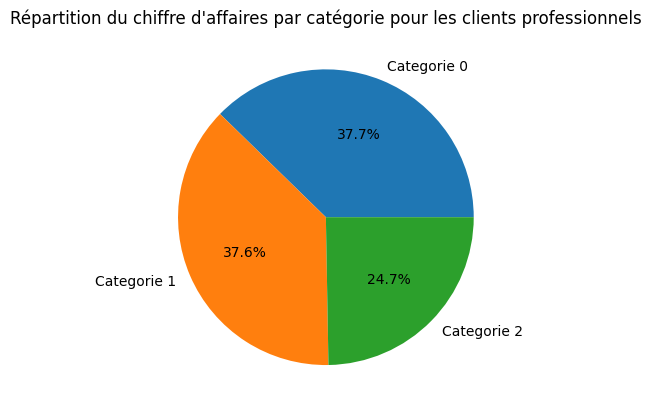

In [ ]:
# Calculate the proportion of the price on the total turnover

customer_category_revenue = customers_transactions_products_df[customers_transactions_products_df["type_customer"] == "Professionnels"]\
.groupby('category', as_index=False)['price'].sum()

print(customer_category_revenue)

plt.pie(data= customer_category_revenue,
        x="price",
                   labels=['Categorie ' + str(cat) for cat in customer_category_revenue["category"].unique()],
                   autopct='%1.1f%%')
plt.xlabel('')
plt.title('Répartition du chiffre d\'affaires par catégorie pour les clients professionnels')
plt.show()

## **Evolution de la clientèle dans le temps**

/tmp/ipython-input-4008671912.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
/tmp/ipython-input-4008671912.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)


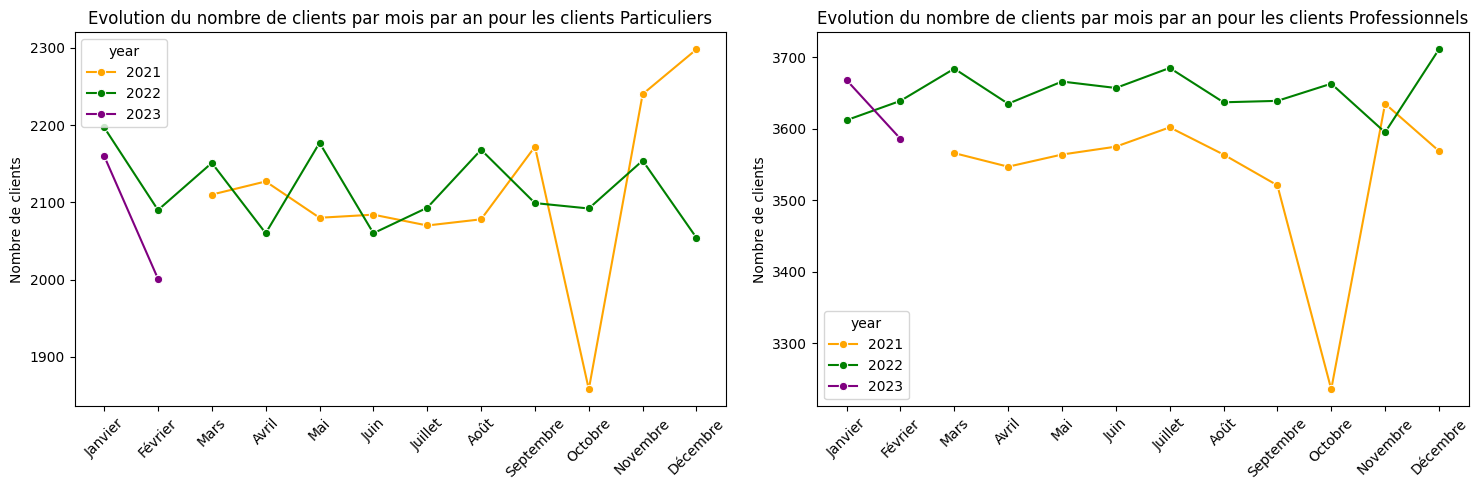

In [ ]:
# Determine the évolution of the customers accross the months and years for the two categories
type_customers_evolution = customers_transactions_products_df.groupby(['year', 'month', 'type_customer'], as_index=False)['client_id'].nunique()
type_customers_evolution.sort_values(["year", "month"], ascending=True, inplace=True)

type_customers_evolution["month_name"] = month_number_to_name(type_customers_evolution["month"])

fig, ax = plt.subplots(1, type_customers_evolution['type_customer'].nunique(), figsize=(15, 5))
for i, type_customer in enumerate(type_customers_evolution['type_customer'].unique()):
  data_type_customer = type_customers_evolution[type_customers_evolution["type_customer"] == type_customer]
  ax[i].set_title(f'Evolution du nombre de clients par mois par an pour les clients {type_customer}')
  sns.lineplot(data=data_type_customer,
                 x='month_name',
                 y='client_id',
               hue='year',
               marker='o',
               ax=ax[i],
               palette=['orange', 'green', 'purple']) # Use palette instead of colors
  ax[i].set_xlabel('')
  ax[i].set_ylabel('Nombre de clients')
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=45)
plt.subplots_adjust(wspace=0.8)
plt.tight_layout()
plt.show()

La **clientèle professionnelle** est en **nette progression entre 2021 et 2022**, au détriment de la clientèle particulière.  
Cette évolution confirme la **stratégie de l'entreprise visant à privilégier une clientèle professionnelle** plutôt qu'une clientèle de particuliers.

# **Corrélations**

Afin de réaliser l'ensemble des analyses de corrélation, les données doivent être **harmonisées**.  
C'est pourquoi certains clients, bien qu'ils génèrent du chiffre d'affaires, seront **exclus des tests**, afin de garantir la **cohérence et la comparabilité des résultats**.

In [ ]:
# get rid of the top 4 customers
top_4_customers = customers_transactions_products_df.groupby('client_id', as_index=False)['price'].sum()\
.sort_values('price', ascending=False).head(4)

In [ ]:
customers_transactions_products_less4_df = customers_transactions_products_df[~customers_transactions_products_df['client_id'].isin(top_4_customers['client_id'])]

In [ ]:
top_4_customers["client_id"]

,client_id
677,c_1609
4388,c_4958
6337,c_6714
2724,c_3454


In [ ]:
customers_transactions_products_df["category"].isna().sum()

np.int64(0)

In [ ]:
customers_transactions_products_less4_df["category"].isna().sum()

np.int64(0)

In [ ]:
# definition of alpha = 0.05 to specify what is the variation accepted to determine
# whether or not a hypothesis is validated or not
alpha = 0.05

## **Genre et catégorie**

L’étude du lien entre le **genre du client** et la **catégorie de produits** porte sur **deux variables qualitatives** appartenant à **deux groupes indépendants**.  
Les tests statistiques les plus appropriés dans ce contexte sont le **test du Khi-deux d’indépendance** ou, le cas échéant, le **test exact de Fisher**.

Le choix entre ces deux tests dépendra de certains critères, notamment des **effectifs théoriques**, qui seront examinés ultérieurement.

Nous formulons alors les hypothèses suivantes :

- **H0 (hypothèse nulle)** : le genre du client et la catégorie de produits sont **indépendants** ; il n’existe **aucune association** entre les deux variables.  
- **H1 (hypothèse alternative)** : le genre du client et la catégorie de produits sont **dépendants** ; il existe **une association** entre les deux variables.


In [ ]:
cross_tab_sex_category = pd.crosstab(customers_transactions_products_less4_df['sex'], customers_transactions_products_less4_df['category'])
cross_tab_sex_category

category,0,1,2
sex,,,
f,200546,111199,16953
m,186308,100886,15806


Un dataset avec un nombre de valeurs dans chaque cellule > 5 donc test de chi-square envisageable plutôt que celui de Fisher

In [ ]:
# Chi2 pour comparer si deux groupes sont indépendants ou non
chi2, pvalue, dof, expected = chi2_contingency(cross_tab_sex_category)

print(f'Khi2 value: {chi2:.2f}')
print(f'P-value: {pvalue}')

if pvalue < alpha:
    print('Hypothèse nulle rejetée : le "Genre" et la "Catégorie" semblent dépendants l\'un de l\'autre')
else:
    print('Nous ne pouvons pas rejeter l\'hypothèse nulle selon laquelle le "Genre" et la "Catégorie" sont indépendants')

Khi2 value: 20.29
P-value: 3.9293409255742534e-05
Hypothèse nulle rejetée : le "Genre" et la "Catégorie" semblent dépendants l'un de l'autre


Les résultats mettent en évidence une association significative entre le genre du client et les catégories de produits achetées, suggérant des comportements d'achat différenciés selon le genre.

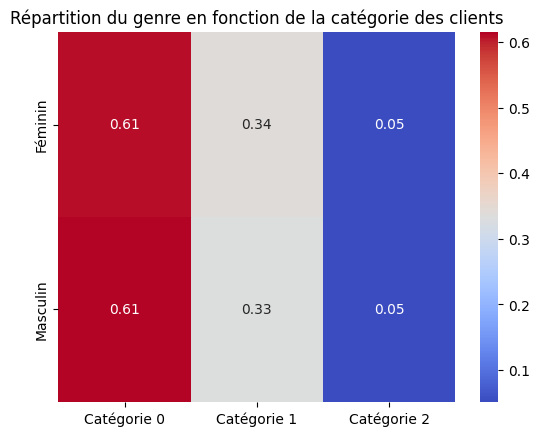

In [ ]:
# Corrected colormap name
cross_tab_sex_category.index = ['Féminin', 'Masculin']
cross_tab_sex_category.columns = ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']

# normalize the values to check how gender are distributed within categories
cross_sex_category_norm = cross_tab_sex_category.div(cross_tab_sex_category.sum(axis=1), axis=0)

sns.heatmap(cross_sex_category_norm, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Répartition du genre en fonction de la catégorie des clients")
plt.show()

Après avoir mis en évidence une **association significative entre le genre et la catégorie de produits**, l'analyse de la **heatmap** permet de visualiser la **répartition de la clientèle**.  
La **catégorie 0** concentre la **majorité des clients**, aussi bien **masculins que féminins**, indiquant qu'il s'agit de la catégorie la plus représentative.

In [ ]:
# print the correlation
def display_correlation(method_value, pvalue, field1, field2):
    if pvalue < alpha:
      if method_value < 0:
        print(f'{field1} et le {field2} sont négativement corrélés')
      else:
        print(f'{field1} et le {field2} sont positivement corrélés')
    else:
        print(f'Échec du rejet de l\'hypothèse nulle : "{field1}" et "{field2}" ne semblent pas avoir de corrélation')

## **Corrélation entre l'âge et le montant total des achats**

Les tests les plus appropriés pour étudier le lien entre **deux variables quantitatives** sont la **corrélation de Pearson** et la **corrélation de Spearman**.  
Le choix entre ces deux méthodes dépendra de plusieurs critères, notamment la **distribution des données**, la **présence de valeurs aberrantes** et la **nature de la relation** entre les variables.

Dans un premier temps, nous formulons les hypothèses statistiques suivantes :

- **H0 (hypothèse nulle)** : il n'existe **aucune corrélation** entre l'âge et le **montant total des achats**.  
- **H1 (hypothèse alternative)** : il existe une **corrélation significative**, positive ou négative, entre l'âge et le **montant total des achats**.

In [ ]:
# Corrélation entre l'âge et le montant total des achats
age_total_purchase = customers_transactions_products_less4_df.groupby('age', as_index=False).agg(
    total_achats=('price', "sum")
)

In [ ]:
total_achats_title = "Répartition du montant des achats par client"
age_title = "Répartion de l'âge"

Est-ce que les deux variables sont équitablement distribuées ?

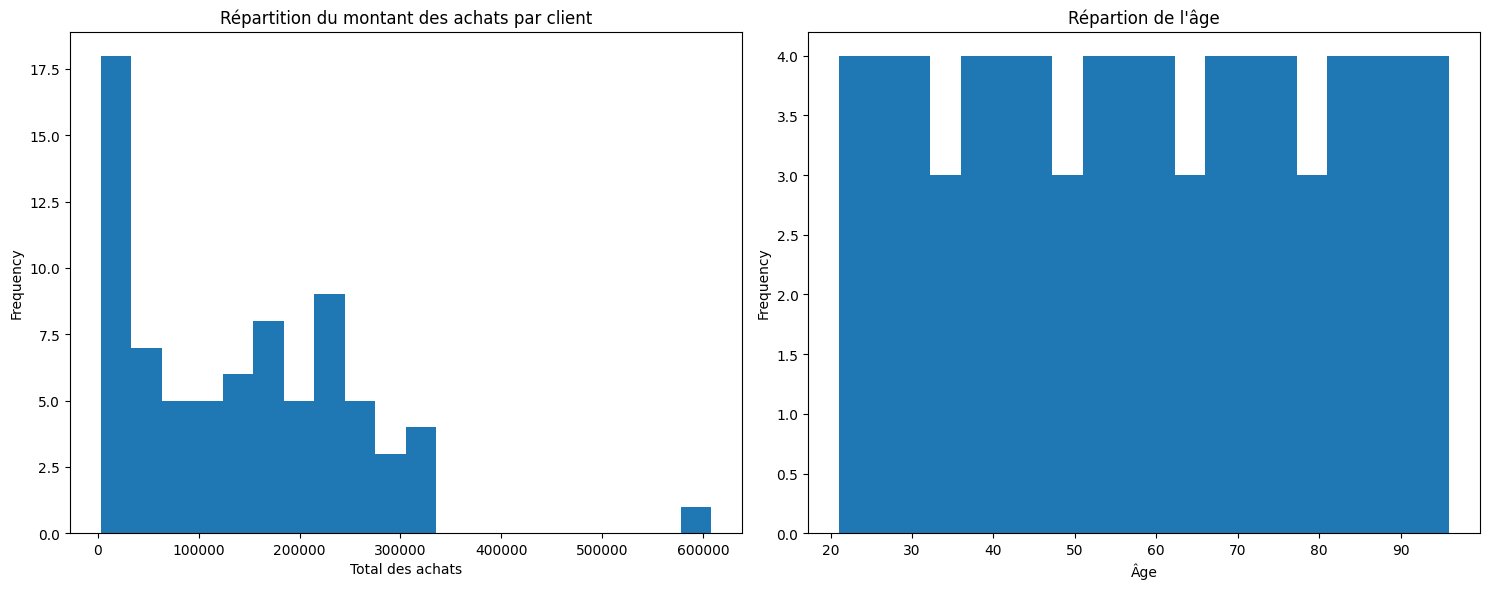

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
age_total_purchase["total_achats"].plot(kind='hist', bins=20, ax=ax[0])
ax[0].set_title(total_achats_title)
ax[0].set_xlabel("Total des achats")
age_total_purchase["age"].plot(kind="hist", bins=20, ax=ax[1])
ax[1].set_title(age_title)
ax[1].set_xlabel("Âge")
plt.tight_layout()
plt.show()

Les valeurs ne sont pas équitablement distribuées, le test de Spearman semble plus adéquat

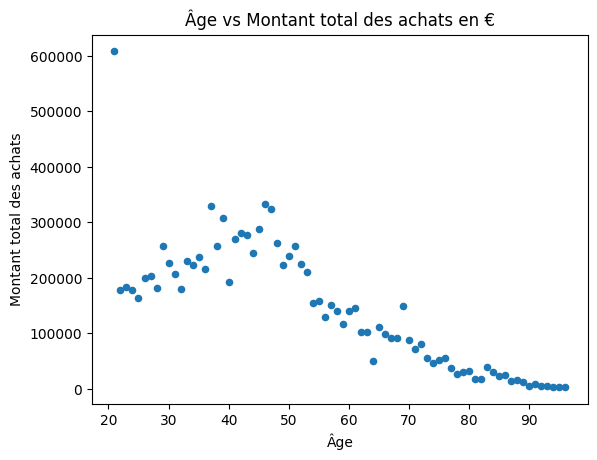

In [ ]:
# nous voulons afficher la manière dont ces deux valeurs sont corrélées
age_total_purchase.plot(kind='scatter', x='age', y='total_achats')
plt.xlabel('Âge')
plt.ylabel('Montant total des achats')
plt.title('Âge vs Montant total des achats en €')
plt.show()

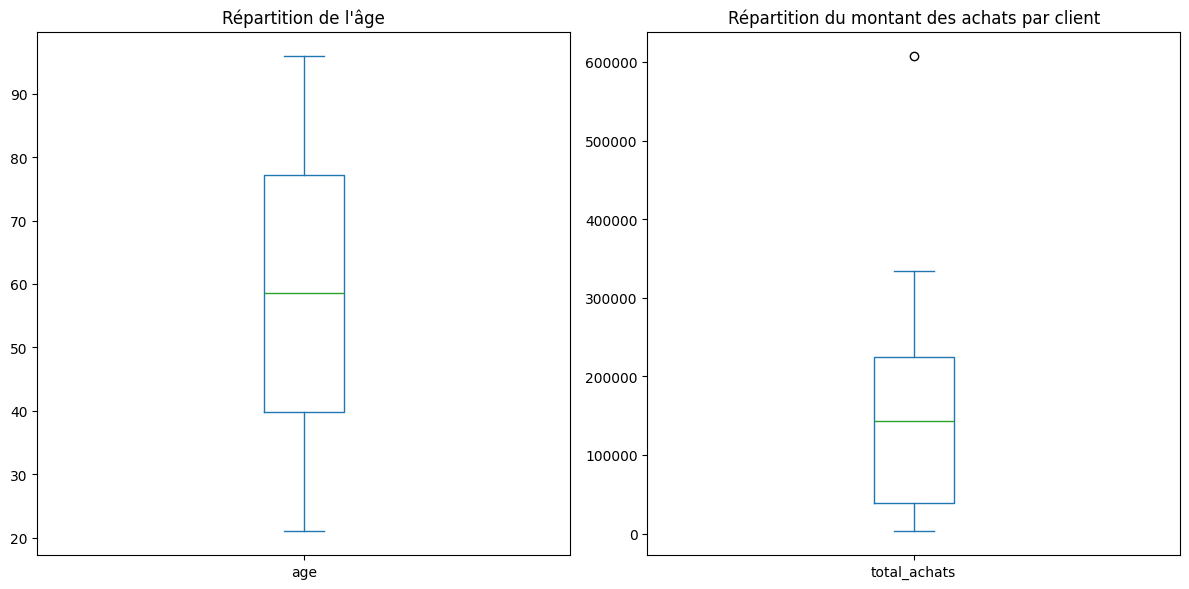

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
age_total_purchase["age"].plot(kind="box", ax=ax[0])
ax[0].set_title("Répartition de l'âge")

age_total_purchase["total_achats"].plot(kind="box", ax=ax[1])
ax[1].set_title("Répartition du montant des achats par client")

plt.tight_layout()
plt.show()

L'exclusion d'un outlier au niveau du prix peut peut-être améliorer l'efficacité des tests statistiques

In [ ]:
age_total_purchase = age_total_purchase[age_total_purchase["total_achats"] < 600000]

Le graphique en point montre que les deux valeurs sont corrélés négativement. Plus l'âge avance et plus le montant dépensé diminue.

In [ ]:
spear, pvalue = spearmanr(age_total_purchase['age'], age_total_purchase['total_achats'])

print(f'Coefficient de corrélation de spearman: {spear:.2f}')
print(f'Valeur p : {pvalue}')

display_correlation(spear, pvalue, "Âge", "Montant total des achats")

Coefficient de corrélation de spearman: -0.87
Valeur p : 5.906320417882705e-24
Âge et le Montant total des achats sont négativement corrélés


Essayons quand même avec Pearson

In [ ]:
pears, pvalue = pearsonr(age_total_purchase['age'], age_total_purchase['total_achats'])
print(f'Coefficient de corrélation de Pearson: {spear:.2f}')
print(f'Valeur p : {pvalue}')

display_correlation(spear, pvalue, "Âge", "Montant total des achats")

Coefficient de corrélation de Pearson: -0.87
Valeur p : 1.6222049290864789e-22
Âge et le Montant total des achats sont négativement corrélés


**Conclusion:** Après suppression d'un outlier sur le prix et visualisation des valeurs via un scatter plot, les deux valeurs ont une corrélation négative.
**Le montant total des achats décroit plus l'âge croit.**
L'hypothèse alternative est donc celle qui est valable car pvalue < alpha

## **Corrélations entre l'âge et la fréquence d'achats**

Afin d'évaluer l'existence d'un lien de corrélation entre **deux variables numériques** — l'**âge** et la **fréquence d'achat** — le choix s'effectue entre la **corrélation de Pearson** et la **corrélation de Spearman**, en fonction des caractéristiques des données (normalité, linéarité, présence de valeurs aberrantes).

Les hypothèses statistiques formulées sont les suivantes :

- **H0 (hypothèse nulle)** : l'âge et la fréquence d'achat sont **non corrélés** ; aucune relation statistique significative n'existe entre ces deux variables.  
- **H1 (hypothèse alternative)** : l'âge et la fréquence d'achat présentent une **corrélation statistiquement significative**, positive ou négative.


In [ ]:
# Corr between age and purchases frequency
corr_age_frequency_grp = customers_transactions_products_less4_df.groupby('age', as_index=False)['date'].count()

In [ ]:
date_title = "Répartition des dates de transaction"
age_title = "Répartition de l'âge des clients"

**Est-ce que les valeurs sont équitablement réparties ?**

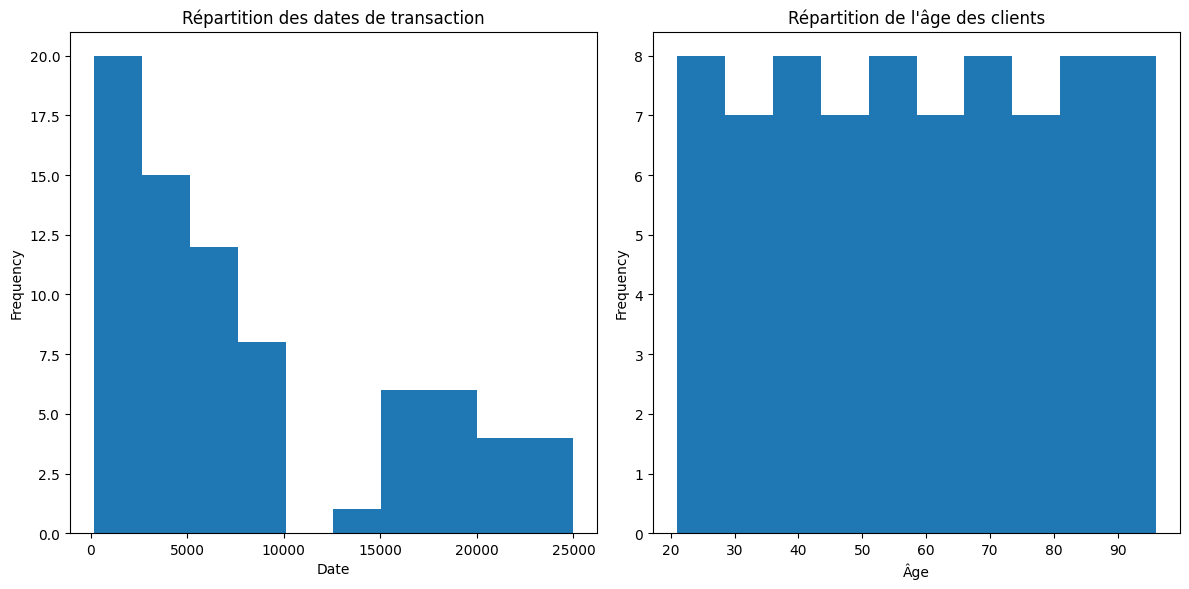

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

corr_age_frequency_grp["date"].plot(kind='hist', ax=ax[0])
ax[0].set_title(date_title)
ax[0].set_xlabel("Date")

corr_age_frequency_grp["age"].plot(kind="hist", ax=ax[1])
ax[1].set_title(age_title)
ax[1].set_xlabel("Âge")

plt.tight_layout()
plt.show()

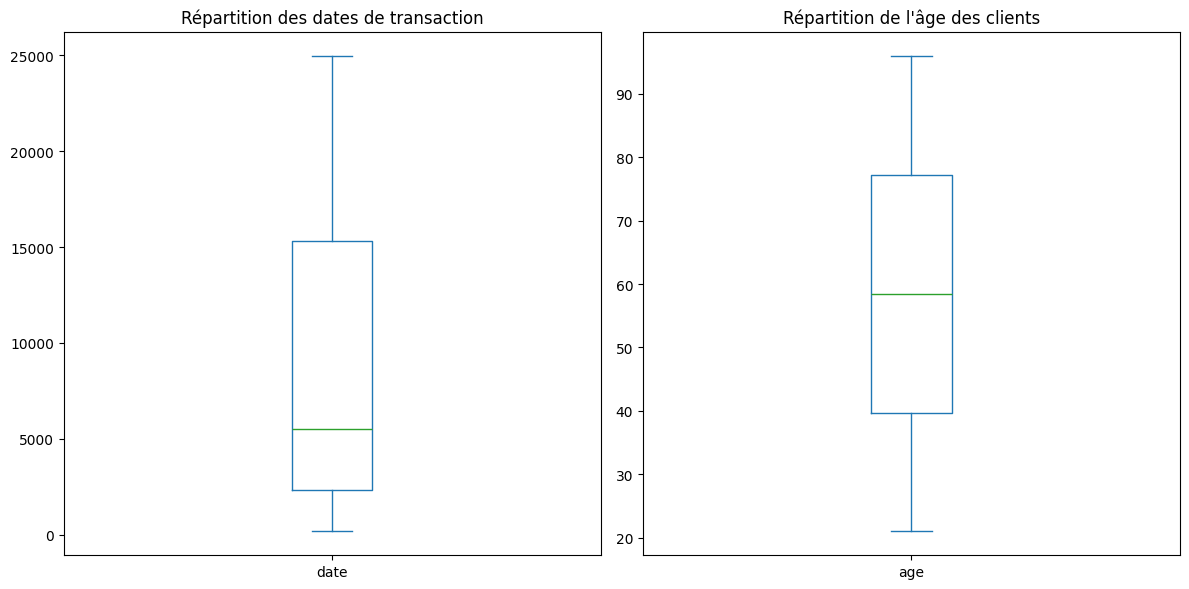

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

corr_age_frequency_grp["date"].plot(kind="box", ax=ax[0])
ax[0].set_title(date_title)

corr_age_frequency_grp["age"].plot(kind="box", ax=ax[1])
ax[1].set_title(age_title)

plt.tight_layout()
plt.show()

La fréquence d'achat n'est pas distribué équitablement, ce qui empêche d'utiliser le test de Pearson, c'est pourquoi, nous évaluerons le lien entre les deux valeurs par Spearman

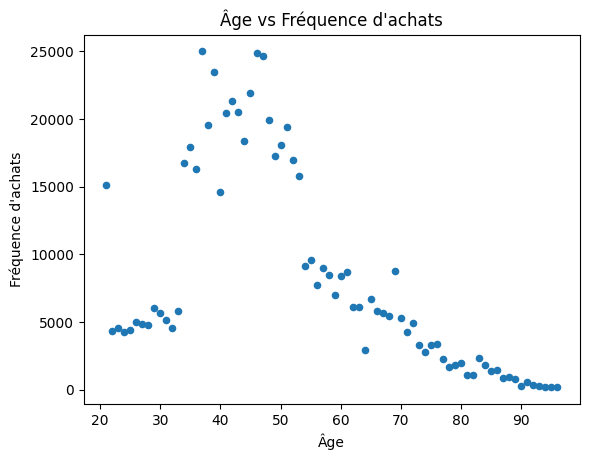

In [ ]:
corr_age_frequency_grp.plot(kind='scatter', x='age', y='date')
plt.xlabel('Âge')
plt.ylabel("Fréquence d'achats")
plt.title("Âge vs Fréquence d'achats")
plt.show()

In [ ]:
spear, pvalue = spearmanr(corr_age_frequency_grp['age'], corr_age_frequency_grp['date'])

print(f'Coefficient de corrélation de Spearman : {spear:.2f}')
print(f'Valeur p : {pvalue}')

print("L'âge et la fréquence d'achats ont un lien de corrélation négatif. Plus l'âge avance et plus la fréquence d'achat diminue")

Coefficient de corrélation de Spearman : -0.67
Valeur p : 2.8597253422208146e-11
L'âge et la fréquence d'achats ont un lien de corrélation négatif. Plus l'âge avance et plus la fréquence d'achat diminue


**Conclusion: A partir de l'âge de 60 ans, les gens achètent beaucoup moins**

## **Corrélation entre l'âge et les achats moyens**

Les mêmes tests que pour les précédentes analyses quantitatives sont envisagés, à savoir la **corrélation de Pearson** ou la **corrélation de Spearman**, en fonction des propriétés des données.

Les hypothèses statistiques sont formulées comme suit :

- **H0 (hypothèse nulle)** : il n’existe **aucune corrélation** entre l’âge et le **montant moyen des achats**.  
- **H1 (hypothèse alternative)** : il existe une **corrélation statistiquement significative** entre l’âge et le **montant moyen des achats**.

In [ ]:
# Corrélation entre l'âge et les achats moyens
corr_age_avg_purchases_grp = customers_transactions_products_less4_df.groupby('age', as_index=False)['price'].mean()

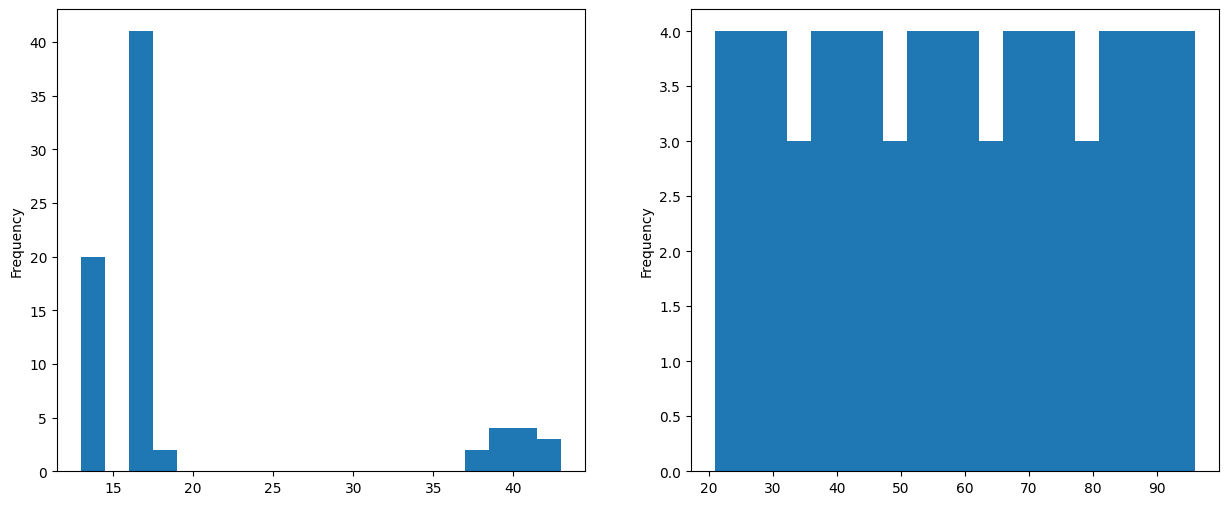

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
corr_age_avg_purchases_grp["price"].plot(kind="hist", bins=20, ax=ax[0])
corr_age_avg_purchases_grp["age"].plot(kind="hist", bins=20, ax=ax[1])
plt.show()

Les valeurs ne sont pas distribués équitablement -> test de Spearman

<Axes: >

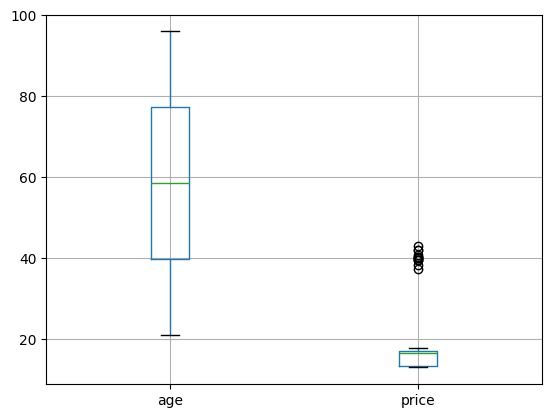

In [ ]:
corr_age_avg_purchases_grp.boxplot()

Regardons s'il existe une corrélation entre les deux valeurs via un scatter plot

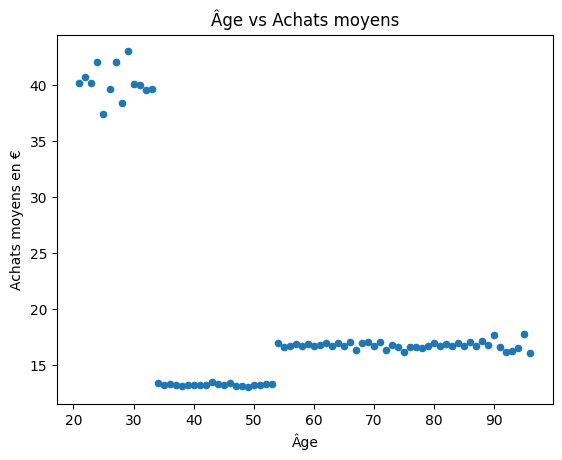

In [ ]:
corr_age_avg_purchases_grp.plot(kind='scatter', x='age', y='price')
plt.xlabel('Âge')
plt.ylabel('Achats moyens en €')
plt.title('Âge vs Achats moyens')
plt.show()

Pas vraiment de corrélation entre les deux valeurs, mais nous pouvons vérifier cela avec les tests.

In [ ]:
spear, pvalue = spearmanr(corr_age_avg_purchases_grp['age'], corr_age_avg_purchases_grp['price'])

print(f'Coefficient de corrélation de Spearman : {spear:.2f}')
print(f"Valeur p : {pvalue}")

print("L'hypothèse nulle n'est pas rejeté. La relation entre l'âge et les achats moyen n'existe pas")

Coefficient de corrélation de Spearman : -0.08
Valeur p : 0.47112036015289716
L'hypothèse nulle n'est pas rejeté. La relation entre l'âge et les achats moyen n'existe pas


Ces résultats suggèrent que **l'âge** n'est **pas un facteur déterminant** dans le **montant moyen des achats**.

## **Corrélation entre l'âge et la catégorie**

L'analyse vise à étudier le lien entre une **variable quantitative** (l'âge), et une **variable qualitative** comportant **trois groupes indépendants**.

Dans ce contexte, les tests statistiques les plus appropriés sont :
- l'**ANOVA à un facteur**,
- ou le **test de Kruskal-Wallis**.

Le choix entre ces deux tests dépendra de critères supplémentaires, notamment :
- la **normalité des distributions**,
- l'**homogénéité des variances**.

**Hypothèses statistiques**

Les hypothèses formulées sont les suivantes :

- **H0 (hypothèse nulle)** : il n'existe **pas de différence significative d'âge** entre les différentes catégories.  
- **H1 (hypothèse alternative)** : il existe **au moins une différence significative d'âge** entre les catégories.


Est-ce que les valeurs son normalement distribués ?

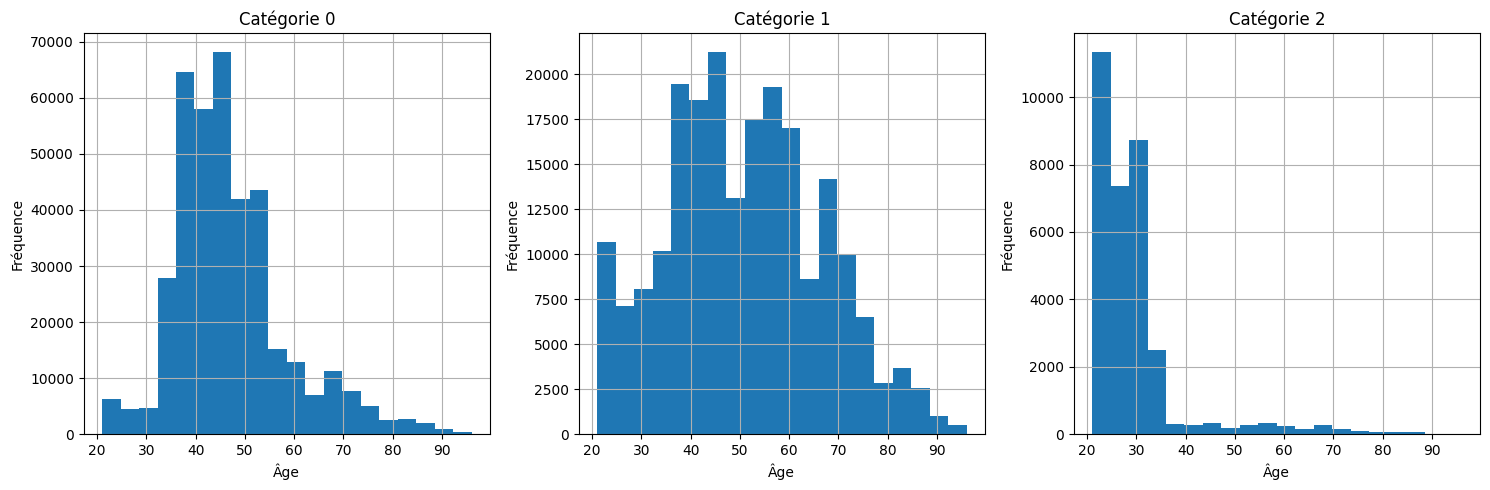

In [ ]:
# We can also check the distribution of each category to see
len_category = len(customers_transactions_products_less4_df['category'].unique())

# I need to draw the number of subplots to display
fig, axes = plt.subplots(1, len_category, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
  distribution_age_category = customers_transactions_products_less4_df.loc[customers_transactions_products_less4_df['category'] == i, 'age']
  distribution_age_category.hist(ax=ax, bins=20)
  ax.set_xlabel('Âge')
  ax.set_ylabel('Fréquence')
  ax.set_title(f'Catégorie {i}')

plt.tight_layout()
plt.show()

Données non équitablement répartis avec beaucoup d'outliers surtout pour la catégorie 2. Test d'ANOVA non pertinent, car sensible à la normalité de la distribution.

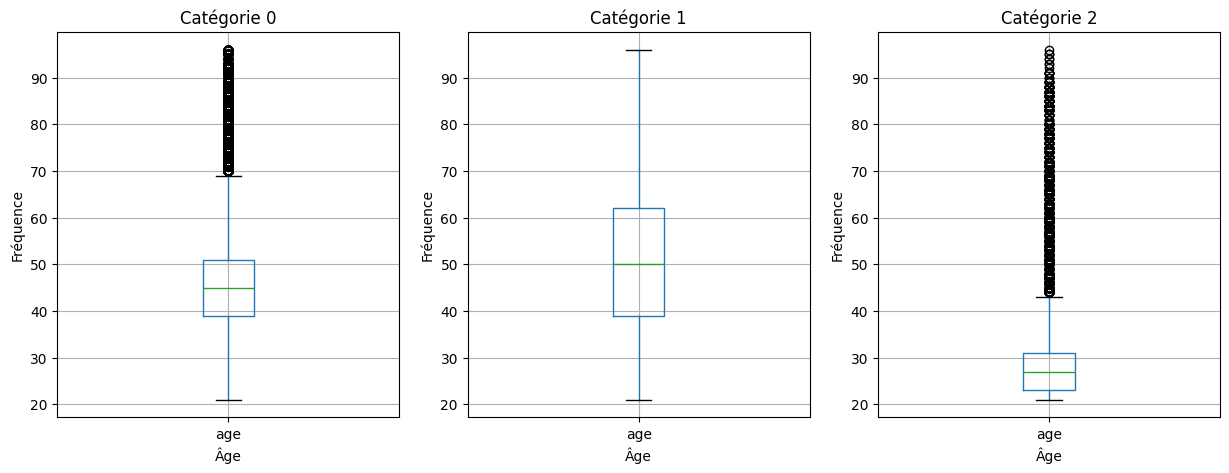

In [ ]:
fig, axes = plt.subplots(1, len_category, figsize=(15, 5))

for i, ax in enumerate(axes.flat):
  distribution_age_category = customers_transactions_products_less4_df.loc[customers_transactions_products_less4_df['category'] == i, ['age']]
  distribution_age_category.boxplot(ax=ax)
  ax.set_xlabel('Âge')
  ax.set_ylabel('Fréquence')
  ax.set_title(f'Catégorie {i}')

plt.show()

Les données semblent aussi dispersées quand à l'analyse de la variance via ce boxplot. Beaucoup d'outliers qui peuvent rendre l'ANOVA caduque.

**Test de Levene** pour valider la visualisation

In [ ]:
group0 = customers_transactions_products_less4_df[customers_transactions_products_less4_df['category'] == 0]['age']
group1 = customers_transactions_products_less4_df[customers_transactions_products_less4_df['category'] == 1]['age']
group2 = customers_transactions_products_less4_df[customers_transactions_products_less4_df['category'] == 2]['age']

In [ ]:
stats, p = levene(group0, group1, group2)
print(f"p-value: {p}")

p-value: 0.0


Absence d'homogénéité de la variance confirmé par p-value < 0.05.
Utilisation du test de Kruskal car homogénéité et normalité non respectés.

In [ ]:
# I will use now kruskal to confirm the hypothesis from Anova to compare the distribution of more than 2 groups

kruskal, pvalue = kruskal(group0, group1, group2)

print(f'Statistique de Kruskal : {kruskal:.2f}')
print(f'Valeur p : {pvalue}')

if pvalue < alpha:
    print('Il existe au moins une différence d\'âge entre les catégories')
else:
    print("Rejet de l'hypothèse de base: Il n'existe pas de preuve qu'il existe une différence d'âge entre les catégories")

Statistique de Kruskal : 71980.52
Valeur p : 0.0
Il existe au moins une différence d'âge entre les catégories


Test d'ANOVA pour confirmer même si les critères ne sont pas respectés

In [ ]:
# Relation between age and category

# Use of Anova to compare one category and one quantitative data for more than 2 groups

foneway, pvalue = f_oneway(group0, group1, group2)

print(f"Test d'ANOVA: {foneway:.2f}")
print(f'P-value: {pvalue}')

if pvalue < alpha:
    print('Il existe au moins une différence d\'âge entre les catégories')
else:
    print('Pas de preuve solide qu\'il existe une différence entre les catégories')

Test d'ANOVA: 40266.77
P-value: 0.0
Il existe au moins une différence d'âge entre les catégories


Les deux tests statistiques confirment l’existence d’**au moins une différence significative d’âge entre les catégories**.  
Cette conclusion est cohérente avec l’analyse visuelle, qui met en évidence des **écarts d’âge particulièrement marqués pour les catégories 0 et 2**, la **catégorie 2** apparaissant comme la **plus déséquilibrée**.

# **Conclusion**

De manière générale, l'ensemble des **indicateurs analysés à la demande de l'entreprise** montre une **nette progression entre 2021 et 2022**.  
L'année **2023** ne peut toutefois pas faire l'objet de conclusions définitives, celle-ci n'étant **pas encore achevée**.

L'analyse fondée sur la **loi de Pareto** et la **courbe de Lorenz** met en évidence le rôle **prépondérant de la clientèle professionnelle** dans le chiffre d'affaires de l'entreprise, avec une **progression notable par rapport à la clientèle particulière**.  
Néanmoins, lorsqu'on observe la **répartition globale des clients**, celle-ci demeure **relativement équilibrée** entre ces deux segments.

L'étude des **corrélations et relations statistiques** entre les différentes variables permet de dégager plusieurs enseignements clés :
- Certaines catégories de produits attirent davantage un genre que l'autre, **notamment les catégories 0 et 1**.
- Une **relation négative** est observée entre l'âge et plusieurs indicateurs de performance client (nombre d'achats, fréquence d'achat et panier moyen).  
  Les résultats suggèrent l'existence d'un **âge pivot situé autour de 60 ans**, au-delà duquel ces indicateurs diminuent.
- Certaines catégories attirent une clientèle **hétérogène en termes d'âge**, en particulier la **catégorie 2**, majoritairement composée de clients âgés de **20 à 40 ans**.

# **Recommendations**

**1. Renforcer la relation avec les clients professionnels (B2B)**
Compte tenu de leur **poids croissant dans le chiffre d’affaires**, il est stratégique de consolider la relation avec la clientèle professionnelle via :
- la mise en place d'un **programme de fidélité dédié** ;
- des **réductions progressives en fonction des volumes achetés** ;
- un **système d'abonnement** offrant des **avantages exclusifs** (tarifs préférentiels, priorisation des commandes) ;
- un **service client dédié**, afin d'améliorer la satisfaction et la rétention.

---

**2. Inciter les 20-30 ans à acheter plus régulièrement et à augmenter leur panier**
Cette tranche d'âge présente un **potentiel de croissance** en matière de fréquence et de panier moyen. Les leviers suivants peuvent être activés :
- une communication renforcée sur les **réseaux sociaux**, notamment **Instagram** ;
- des **sélections de livres personnalisées** et des recommandations ciblées ;
- des **bons de réduction** applicables sur les prochains achats, accompagnés de **recommandations complémentaires** ;
- des **offres promotionnelles attractives** (ex. *3 pour le prix de 2*) ;
- un **système d'abonnement dégressif**, favorisant l'engagement sur la durée.

---

**3. Inciter les 30-60 ans à augmenter leur panier moyen**
Pour cette population, l'objectif principal est l'augmentation du **montant par transaction**. Plusieurs leviers peuvent être mobilisés :
- des **promotions exceptionnelles régulières** ;
- la **gratuité des frais de livraison** à partir d'un seuil d'achat défini ;
- la proposition de **plusieurs niveaux de livraison** (standard, rapide, premium), combinés à des options de livraison **localisées** (domicile, points relais).
